# Flight Delay Prediction

Notebook com 2 modelos para prever se um voo irá atrasar com base em informações operacionais como companhia aérea, aeroporto de origem, aeroporto de destino, horário programado e distância do voo.

**Problema de classificação**
- `0` → voo sem atraso significativo
- `1` → voo com atraso superior a 15 minutos

## Importação de bibliotecas

In [3]:
# Manipulação de dados
import pandas as pd
import numpy as np
from pathlib import Path

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

sns.set(style="whitegrid")
SEED = 42
SAMPLE_SIZE = 300000

## Configuração dos caminhos dos arquivos

Salvar os datasets na pasta `../data/`, para facilitar a execução local.

In [4]:
possible_base_dirs = [
    Path("."),
    Path("data"),
    Path("../data")
]

def find_file(filename: str) -> Path:
    for base in possible_base_dirs:
        candidate = base / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Arquivo não encontrado: {filename}")

FLIGHTS_PATH = find_file("flights.csv")
AIRLINES_PATH = find_file("airlines.csv")
AIRPORTS_PATH = find_file("airports.csv")

print("flights.csv ->", FLIGHTS_PATH)
print("airlines.csv ->", AIRLINES_PATH)
print("airports.csv ->", AIRPORTS_PATH)

flights.csv -> data/flights.csv
airlines.csv -> data/airlines.csv
airports.csv -> data/airports.csv


## Carregamento dos dados

In [5]:
df = pd.read_csv(FLIGHTS_PATH, nrows=SAMPLE_SIZE, low_memory=False)
airlines = pd.read_csv(AIRLINES_PATH)
airports = pd.read_csv(AIRPORTS_PATH)

print("Shape inicial:", df.shape)
df.head()

Shape inicial: (300000, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## Análise inicial dos dados

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 300000 non-null  int64  
 1   MONTH                300000 non-null  int64  
 2   DAY                  300000 non-null  int64  
 3   DAY_OF_WEEK          300000 non-null  int64  
 4   AIRLINE              300000 non-null  str    
 5   FLIGHT_NUMBER        300000 non-null  int64  
 6   TAIL_NUMBER          299505 non-null  str    
 7   ORIGIN_AIRPORT       300000 non-null  str    
 8   DESTINATION_AIRPORT  300000 non-null  str    
 9   SCHEDULED_DEPARTURE  300000 non-null  int64  
 10  DEPARTURE_TIME       294561 non-null  float64
 11  DEPARTURE_DELAY      294561 non-null  float64
 12  TAXI_OUT             294390 non-null  float64
 13  WHEELS_OFF           294390 non-null  float64
 14  SCHEDULED_TIME       300000 non-null  int64  
 15  ELAPSED_TIME         293634 

In [7]:
df.isnull().sum().sort_values(ascending=False).head(15)

CANCELLATION_REASON    294314
LATE_AIRCRAFT_DELAY    227757
WEATHER_DELAY          227757
AIRLINE_DELAY          227757
AIR_SYSTEM_DELAY       227757
SECURITY_DELAY         227757
ELAPSED_TIME             6366
AIR_TIME                 6366
ARRIVAL_DELAY            6366
WHEELS_ON                5870
TAXI_IN                  5870
ARRIVAL_TIME             5870
WHEELS_OFF               5610
TAXI_OUT                 5610
DEPARTURE_TIME           5439
dtype: int64

In [8]:
df.describe(include="all").T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,300000.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,300000.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
DAY,300000.0,NaN,NaN,NaN,10.231673,5.676179,1.0,5.0,10.0,15.0,20.0
DAY_OF_WEEK,300000.0,NaN,NaN,NaN,4.018087,2.035068,1.0,2.0,4.0,6.0,7.0
AIRLINE,300000,14,WN,63691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,300000.0,NaN,NaN,NaN,2262.073127,1807.573049,1.0,759.0,1727.0,3479.0,9793.0
TAIL_NUMBER,299505,4333,N484HA,248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,300000,312,ATL,18639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,300000,312,ATL,18763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,300000.0,NaN,NaN,NaN,1317.587673,467.861041,5.0,920.0,1315.0,1714.0,2359.0


## Limpeza dos dados e criação da variável alvo

Como o objetivo é prever atraso na chegada, removemos voos cancelados e criamos a variável binária `is_delayed`.

In [9]:
df = df[df["CANCELLED"] == 0].copy()
print("Shape após remover cancelados:", df.shape)

df["is_delayed"] = (df["ARRIVAL_DELAY"] > 15).astype(int)

print("\nDistribuição absoluta da variável alvo:")
print(df["is_delayed"].value_counts())

print("\nDistribuição relativa da variável alvo:")
print(df["is_delayed"].value_counts(normalize=True))

Shape após remover cancelados: (294314, 31)

Distribuição absoluta da variável alvo:
is_delayed
0    224523
1     69791
Name: count, dtype: int64

Distribuição relativa da variável alvo:
is_delayed
0    0.762869
1    0.237131
Name: proportion, dtype: float64


## Enriquecimento com tabelas auxiliares

- `airlines.csv` → nome completo da companhia aérea  
- `airports.csv` → informações dos aeroportos de origem e destino

In [10]:
# Merge com companhias aéreas
df = df.merge(
    airlines,
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left"
)

df = df.rename(columns={
    "AIRLINE_x": "AIRLINE",
    "AIRLINE_y": "AIRLINE_NAME"
})

df = df.drop(columns=["IATA_CODE"])

# Merge com aeroportos de origem
df = df.merge(
    airports,
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

df = df.rename(columns={
    "AIRPORT": "ORIGIN_AIRPORT_NAME",
    "CITY": "ORIGIN_CITY",
    "STATE": "ORIGIN_STATE"
})

df = df.drop(columns=["IATA_CODE", "COUNTRY", "LATITUDE", "LONGITUDE"])

# Merge com aeroportos de destino
df = df.merge(
    airports,
    left_on="DESTINATION_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

df = df.rename(columns={
    "AIRPORT": "DEST_AIRPORT_NAME",
    "CITY": "DEST_CITY",
    "STATE": "DEST_STATE"
})

df = df.drop(columns=["IATA_CODE", "COUNTRY", "LATITUDE", "LONGITUDE"])

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,is_delayed,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,NaN,NaN,0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,Seattle-Tacoma International Airport,Seattle,WA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,NaN,NaN,0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Palm Beach International Airport,West Palm Beach,FL
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,NaN,NaN,0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,Charlotte Douglas International Airport,Charlotte,NC
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,NaN,NaN,0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Miami International Airport,Miami,FL
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,NaN,NaN,0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,Ted Stevens Anchorage International Airport,Anchorage,AK


##  Feature criada para auxiliar na Análise exploratória

Criamos `hour` e `period` para facilitar tanto a análise quanto a modelagem.

In [11]:
df["hour"] = df["SCHEDULED_DEPARTURE"] // 100

def period(hour):
    if hour < 6:
        return "madrugada"
    elif hour < 12:
        return "manha"
    elif hour < 18:
        return "tarde"
    return "noite"

df["period"] = df["hour"].apply(period)

df[["SCHEDULED_DEPARTURE", "hour", "period"]].head()

,SCHEDULED_DEPARTURE,hour,period
0,5,0,madrugada
1,10,0,madrugada
2,20,0,madrugada
3,20,0,madrugada
4,25,0,madrugada


## Análise exploratória (EDA)

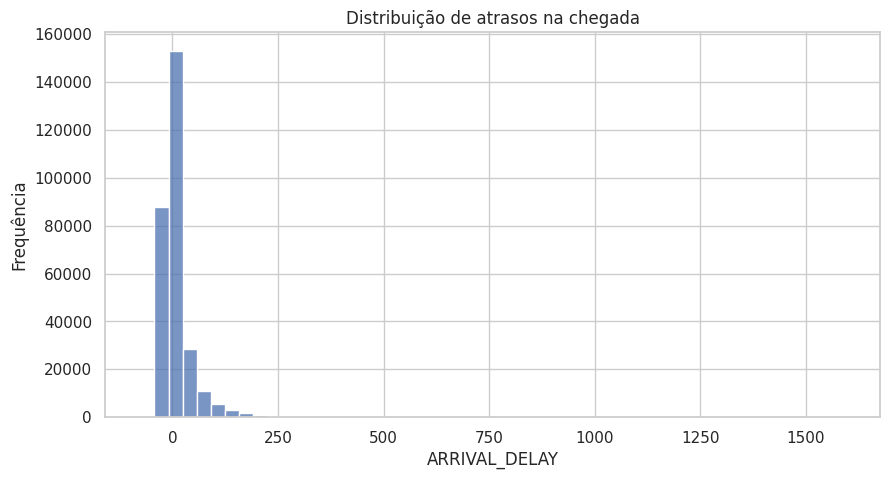

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df["ARRIVAL_DELAY"], bins=50)
plt.title("Distribuição de atrasos na chegada")
plt.xlabel("ARRIVAL_DELAY")
plt.ylabel("Frequência")
plt.show()

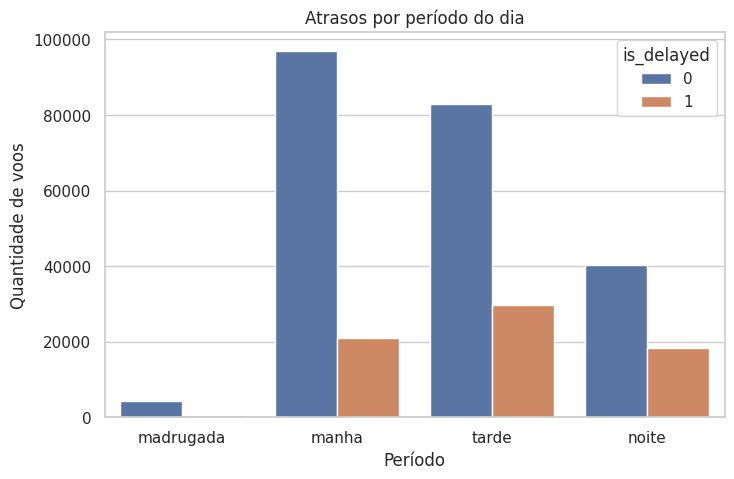

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="period", hue="is_delayed")
plt.title("Atrasos por período do dia")
plt.xlabel("Período")
plt.ylabel("Quantidade de voos")
plt.show()

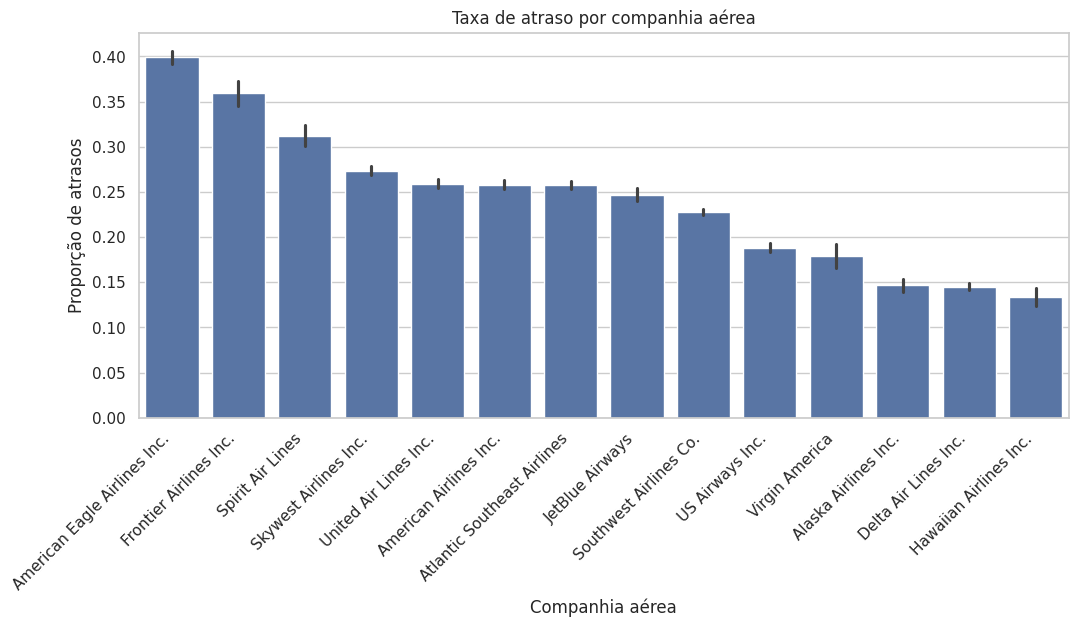

In [14]:
plt.figure(figsize=(12, 5))
airline_order = (
    df.groupby("AIRLINE_NAME")["is_delayed"]
      .mean()
      .sort_values(ascending=False)
      .index
)

sns.barplot(data=df, x="AIRLINE_NAME", y="is_delayed", order=airline_order)
plt.xticks(rotation=45, ha="right")
plt.title("Taxa de atraso por companhia aérea")
plt.xlabel("Companhia aérea")
plt.ylabel("Proporção de atrasos")
plt.show()

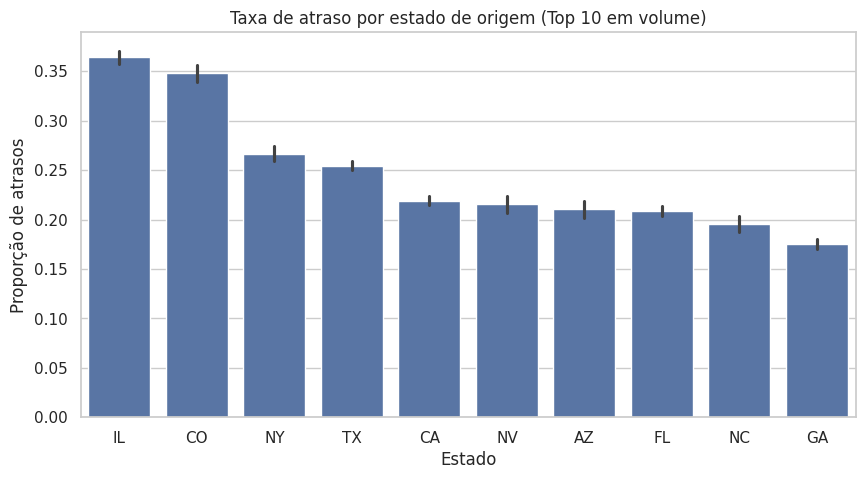

In [15]:
plt.figure(figsize=(10, 5))
top_states = df["ORIGIN_STATE"].value_counts().head(10).index
state_order = (
    df[df["ORIGIN_STATE"].isin(top_states)]
      .groupby("ORIGIN_STATE")["is_delayed"]
      .mean()
      .sort_values(ascending=False)
      .index
)

sns.barplot(
    data=df[df["ORIGIN_STATE"].isin(top_states)],
    x="ORIGIN_STATE",
    y="is_delayed",
    order=state_order
)

plt.title("Taxa de atraso por estado de origem (Top 10 em volume)")
plt.xlabel("Estado")
plt.ylabel("Proporção de atrasos")
plt.show()

## Seleção de features para modelagem

Usamos apenas variáveis conhecidas antes da decolagem para evitar **data leakage**.

In [16]:
features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "DISTANCE",
    "SCHEDULED_TIME"
]

X = df[features].copy()
y = df["is_delayed"]

X["hour"] = X["SCHEDULED_DEPARTURE"] // 100
X["period"] = X["hour"].apply(period)
X = X.drop(columns=["SCHEDULED_DEPARTURE"])

X.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_TIME,hour,period
0,1,1,4,AS,ANC,SEA,1448,205,0,madrugada
1,1,1,4,AA,LAX,PBI,2330,280,0,madrugada
2,1,1,4,US,SFO,CLT,2296,286,0,madrugada
3,1,1,4,AA,LAX,MIA,2342,285,0,madrugada
4,1,1,4,AS,SEA,ANC,1448,235,0,madrugada


## Separação entre treino e teste

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribuição de classes no treino:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição de classes no teste:")
print(y_test.value_counts(normalize=True))

X_train: (235451, 10)
X_test : (58863, 10)

Distribuição de classes no treino:
is_delayed
0    0.762868
1    0.237132
Name: proportion, dtype: float64

Distribuição de classes no teste:
is_delayed
0    0.762873
1    0.237127
Name: proportion, dtype: float64


## Pré-processamento

- variáveis numéricas → `StandardScaler`
- variáveis categóricas → `OneHotEncoder`

In [18]:
numeric_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "DISTANCE",
    "SCHEDULED_TIME",
    "hour"
]

categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "period"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Modelo 1 — Logistic Regression

In [19]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED
    ))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1       :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_log))

=== Logistic Regression ===
Accuracy : 0.6503236328423627
Precision: 0.368138211058477
Recall   : 0.6625591058890958
F1       : 0.4732976790603649
ROC-AUC  : 0.7070165640318924


In [20]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.86      0.65      0.74     44905
           1       0.37      0.66      0.47     13958

    accuracy                           0.65     58863
   macro avg       0.61      0.65      0.61     58863
weighted avg       0.74      0.65      0.68     58863



## Modelo 2 — Random Forest

In [21]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1       :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

=== Random Forest ===
Accuracy : 0.7929259466897711
Precision: 0.6123745394486089
Recall   : 0.34532167932368535
F1       : 0.4416143662100875
ROC-AUC  : 0.759425582966789


In [22]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87     44905
           1       0.61      0.35      0.44     13958

    accuracy                           0.79     58863
   macro avg       0.72      0.64      0.66     58863
weighted avg       0.77      0.79      0.77     58863



## Comparação dos modelos

In [23]:
results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.650324,0.368138,0.662559,0.473298,0.707017
1,Random Forest,0.792926,0.612375,0.345322,0.441614,0.759426


<Figure size 800x500 with 0 Axes>

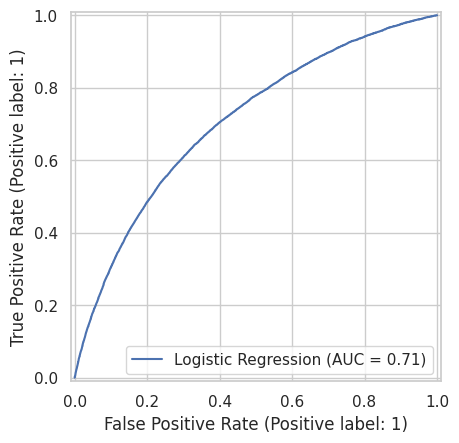

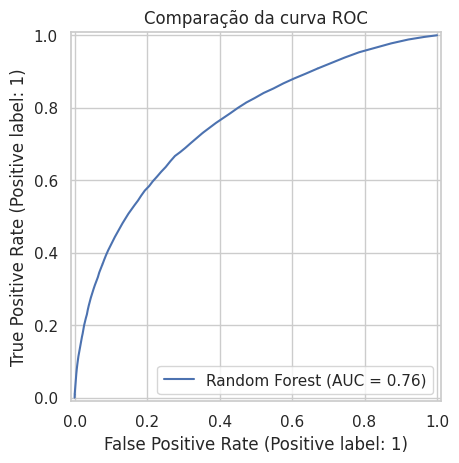

In [24]:
plt.figure(figsize=(8, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
plt.title("Comparação da curva ROC")
plt.show()

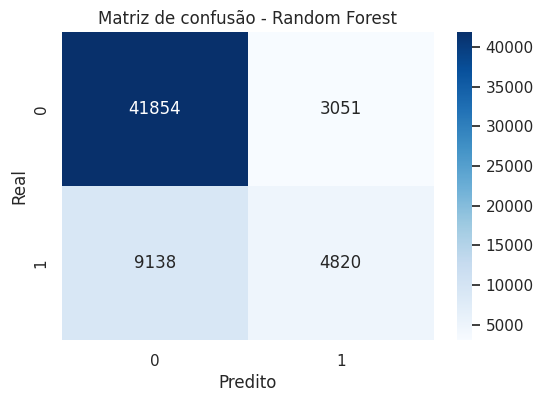

In [25]:
conf_matrix = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## Importância das variáveis no Random Forest

In [26]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_

feat_importance = (
    pd.Series(importances, index=feature_names)
      .sort_values(ascending=False)
)

feat_importance.head(15)

num__DAY                        0.228765
num__DAY_OF_WEEK                0.118870
num__SCHEDULED_TIME             0.105206
num__hour                       0.081478
num__DISTANCE                   0.069840
cat__period_manha               0.010153
cat__AIRLINE_DL                 0.008692
cat__period_noite               0.006881
cat__AIRLINE_MQ                 0.006474
cat__ORIGIN_AIRPORT_ORD         0.006109
cat__AIRLINE_WN                 0.005914
cat__period_tarde               0.005580
cat__DESTINATION_AIRPORT_SFO    0.004815
cat__ORIGIN_AIRPORT_DEN         0.004413
cat__DESTINATION_AIRPORT_ORD    0.004333
dtype: float64

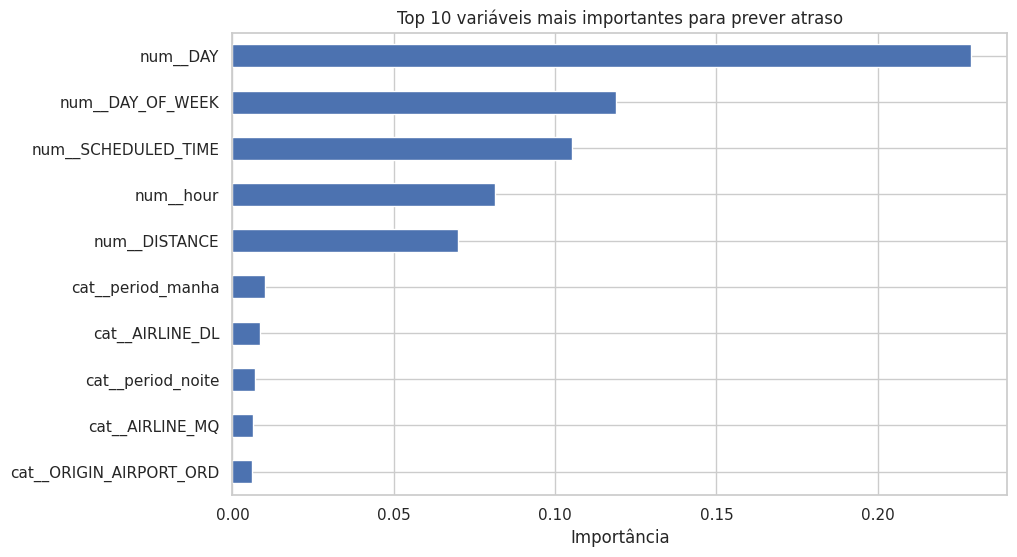

In [27]:
plt.figure(figsize=(10, 6))
feat_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 variáveis mais importantes para prever atraso")
plt.xlabel("Importância")
plt.show()

## Conclusão

Com base nos resultados obtidos:

- a **Logistic Regression** apresentou **recall mais alto**, sendo melhor em identificar voos atrasados;
- o **Random Forest** apresentou melhor desempenho geral em **accuracy**, **precision** e **ROC-AUC**, mostrando melhor capacidade de discriminar voos atrasados e não atrasados;
- a análise exploratória indicou que atrasos tendem a variar por **companhia aérea**, **estado de origem** e **período do dia**.

